# TAE-IA · Module 6 · L20 — Whisper in Practice: Timestamps and Subtitles

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L20 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU |
| **Drive space** | ~0 MB new (reuses Whisper weights from L19) |

## Learning objectives

1. Extract segment-level and word-level timestamps from Whisper
2. Write correctly formatted SRT and VTT subtitle files
3. Chunk a long audio file manually with overlap + deduplication
4. Filter hallucinated segments using `no_speech_prob`
5. Build a one-file Gradio subtitle-generation app

---

## Cell 0 — Setup

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, time, random
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — go to Runtime > Change runtime type > T4 GPU')
print(f'Device: {DEVICE}')

Mounted at /content/drive
GPU: Tesla T4
Device: cuda


In [2]:
# gradio pinned to the version that works in Colab (same as the project);
# gradio 5.6 imports HfFolder, removed in huggingface_hub 1.0 -> pin it too
!pip install openai-whisper gtts librosa soundfile "gradio>=5.6,<5.7" "huggingface_hub<1.0" -q

import whisper
import librosa
import soundfile as sf
from gtts import gTTS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'whisper {whisper.__version__}')

# Load Whisper small — reuses Drive cache from L19
print('\nLoading Whisper small from Drive cache...')
t0 = time.time()
model = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    model = model.to('cuda')
print(f'Loaded in {time.time()-t0:.1f}s')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 48.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.4/118.4 kB 13.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 

## Cell 1b — Output folder

*Celda agregada (decisión propia, no parte del lab original): crea `L20_output` y guarda automáticamente cada figura que se muestra con `plt.show()`.*

In [3]:
# ================================================================
# Output folder + auto-save every figure shown with plt.show()
# ================================================================
import re, json

LESSON     = 'L20'
OUTPUT_DIR = os.path.join(os.path.dirname(MODEL_CACHE), f'{LESSON}_output')
FIG_DIR    = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Keep the real plt.show only once (safe to re-run this cell)
if not hasattr(plt, '_show_original'):
    plt._show_original = plt.show

def _fig_name(fig):
    # File name = suptitle, or first subplot title if there is no suptitle
    title = fig._suptitle.get_text() if fig._suptitle else ''
    if not title and fig.axes:
        title = fig.axes[0].get_title()
    slug = re.sub(r'[^a-z0-9]+', '_', title.lower()).strip('_')[:70]
    return (slug or 'figure') + '.png'

def _show_and_save(*args, **kwargs):
    fig = plt.gcf()
    fig.savefig(os.path.join(FIG_DIR, _fig_name(fig)), dpi=150, bbox_inches='tight')
    plt._show_original(*args, **kwargs)

plt.show = _show_and_save  # same name -> no changes needed in later cells
print(f'Figures will be saved to: {FIG_DIR}')

Figures will be saved to: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L20_output/figures


---
## Section 1 — Helper Functions

Define all helpers up front so every section below can call them.

In [4]:
def seconds_to_srt_time(s):
    """Convert float seconds to SRT timecode HH:MM:SS,mmm."""
    s   = max(0.0, s)
    h   = int(s // 3600)
    m   = int((s % 3600) // 60)
    sec = int(s % 60)
    ms  = int(round((s % 1) * 1000))
    return f'{h:02d}:{m:02d}:{sec:02d},{ms:03d}'

def seconds_to_vtt_time(s):
    """Convert float seconds to VTT timecode HH:MM:SS.mmm."""
    return seconds_to_srt_time(s).replace(',', '.')

def segments_to_srt(segments, max_chars=42, max_lines=2, skip_silence=True):
    """Convert Whisper segment list to SRT string."""
    blocks = []
    counter = 1
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue

        # Word-wrap
        words, lines, current = text.split(), [], []
        for word in words:
            if sum(len(w)+1 for w in current) + len(word) > max_chars and current:
                lines.append(' '.join(current))
                current = []
            current.append(word)
        if current:
            lines.append(' '.join(current))

        text_block = '\n'.join(lines[:max_lines])
        start_tc   = seconds_to_srt_time(seg['start'])
        end_tc     = seconds_to_srt_time(seg['end'])
        blocks.append(f'{counter}\n{start_tc} --> {end_tc}\n{text_block}')
        counter += 1

    return '\n\n'.join(blocks) + '\n'

def segments_to_vtt(segments, skip_silence=True):
    """Convert Whisper segment list to WebVTT string."""
    blocks = ['WEBVTT', '']
    for seg in segments:
        if skip_silence and seg.get('no_speech_prob', 0) > 0.6:
            continue
        text = seg['text'].strip()
        if not text:
            continue
        start_tc = seconds_to_vtt_time(seg['start'])
        end_tc   = seconds_to_vtt_time(seg['end'])
        blocks.append(f'{start_tc} --> {end_tc}\n{text}')
    return '\n\n'.join(blocks) + '\n'

print('Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt')

Helpers defined: seconds_to_srt_time, seconds_to_vtt_time, segments_to_srt, segments_to_vtt


---
## Section 2.1 — Timestamps from a Multi-sentence Recording

Generate a TTS narration with 5 sentences that each cover a distinct topic, then compare segment vs. word timestamps.

In [5]:
NARRATION = (
    "Audio signals are the foundation of speech and music processing. "
    "Fourier analysis decomposes a signal into its frequency components. "
    "The mel scale aligns frequency representation with human auditory perception. "
    "Convolutional neural networks treat spectrograms as two-dimensional images. "
    "Whisper processes audio in thirty-second windows using an encoder-decoder architecture."
)

NARRATION_PATH = '/tmp/narration.mp3'
tts = gTTS(text=NARRATION, lang='en')
tts.save(NARRATION_PATH)

y_narr, sr_narr = librosa.load(NARRATION_PATH, sr=16000, mono=True)
print(f'Narration: {len(y_narr)/sr_narr:.1f}s')
ipd.display(ipd.Audio(y_narr, rate=sr_narr))

Narration: 29.0s


In [6]:
# --- Segment-level timestamps (default) ---
print('Transcribing with segment timestamps...')
result_seg = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'))

print(f'\nDetected language: {result_seg["language"]}')
print(f'Segments: {len(result_seg["segments"])}\n')
print('Segment timeline:')
for seg in result_seg['segments']:
    prob = seg.get('no_speech_prob', 0)
    flag = ' [SILENCE?]' if prob > 0.4 else ''
    print(f"  [{seg['start']:5.2f}s → {seg['end']:5.2f}s]  "
          f"conf={seg['avg_logprob']:.2f}  "
          f"no_speech={prob:.2f}{flag}")
    print(f"    {seg['text'].strip()}")

Transcribing with segment timestamps...

Detected language: en
Segments: 5

Segment timeline:
  [ 0.00s →  4.90s]  conf=-0.22  no_speech=0.02
    Audio signals are the foundation of speech and music processing.
  [ 4.90s → 10.60s]  conf=-0.22  no_speech=0.02
    Fourier analysis decomposes a signal into its frequency components.
  [10.60s → 16.50s]  conf=-0.22  no_speech=0.02
    The MEL scale aligns frequency representation with human auditory perception.
  [16.50s → 22.30s]  conf=-0.22  no_speech=0.02
    Convolutional neural networks treat spectrograms as two-dimensional images.
  [22.30s → 28.90s]  conf=-0.22  no_speech=0.02
    Whisper processes audio in 30-second windows using an encoder-decoder architecture.


In [7]:
# --- Word-level timestamps ---
print('Transcribing with word timestamps (slower)...')
t0 = time.time()
result_word = model.transcribe(NARRATION_PATH, fp16=(DEVICE == 'cuda'),
                               word_timestamps=True)
print(f'Done in {time.time()-t0:.2f}s\n')

# Print word timeline for the first 2 segments
for seg in result_word['segments'][:2]:
    print(f"Segment: \"{seg['text'].strip()}\"")
    for w in seg.get('words', []):
        print(f"  {w['start']:5.2f}–{w['end']:5.2f}  {w['word']!r:<20}  p={w['probability']:.2f}")
    print()

Transcribing with word timestamps (slower)...
Done in 10.56s

Segment: "Audio signals are the foundation of speech and music processing."
   0.00– 0.64  ' Audio'              p=0.98
   0.64– 1.10  ' signals'            p=0.91
   1.10– 1.54  ' are'                p=1.00
   1.54– 1.64  ' the'                p=1.00
   1.64– 2.14  ' foundation'         p=1.00
   2.14– 2.54  ' of'                 p=1.00
   2.54– 2.88  ' speech'             p=1.00
   2.88– 3.12  ' and'                p=0.98
   3.12– 3.44  ' music'              p=1.00
   3.44– 4.22  ' processing.'        p=1.00

Segment: "Fourier analysis decomposes a signal into its frequency components."
   4.94– 5.44  ' Fourier'            p=0.75
   5.44– 6.20  ' analysis'           p=0.90
   6.20– 7.26  ' decomposes'         p=0.99
   7.26– 7.50  ' a'                  p=1.00
   7.50– 7.88  ' signal'             p=1.00
   7.88– 8.24  ' into'               p=1.00
   8.24– 8.48  ' its'                p=1.00
   8.48– 8.92  ' frequency'       

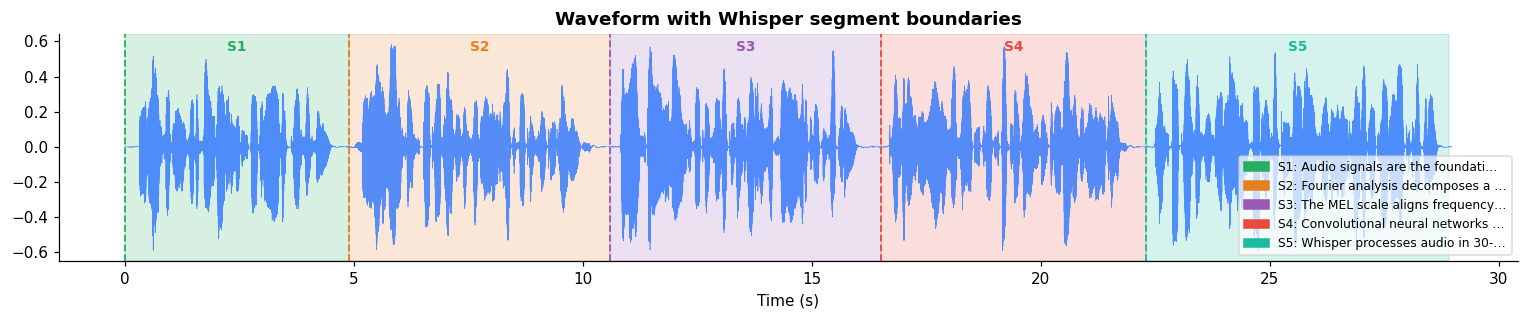

In [8]:
# Visualise the waveform with segment boundaries overlaid
fig, ax = plt.subplots(figsize=(14, 3))

t_axis = np.linspace(0, len(y_narr)/sr_narr, len(y_narr))
ax.plot(t_axis, y_narr, color='#2C75FF', linewidth=0.4, alpha=0.8)

colours = ['#27ae60', '#e67e22', '#9b59b6', '#e74c3c', '#1abc9c']
patches = []
for i, seg in enumerate(result_seg['segments']):
    c = colours[i % len(colours)]
    ax.axvspan(seg['start'], seg['end'], alpha=0.18, color=c)
    ax.axvline(seg['start'], color=c, linewidth=1.2, linestyle='--')
    mid = (seg['start'] + seg['end']) / 2
    ax.text(mid, ax.get_ylim()[1]*0.85, f'S{i+1}',
            ha='center', fontsize=9, color=c, fontweight='bold')
    patches.append(mpatches.Patch(color=c, label=f'S{i+1}: {seg["text"].strip()[:30]}…'))

ax.set_xlabel('Time (s)')
ax.set_title('Waveform with Whisper segment boundaries', fontweight='bold')
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.7)
plt.tight_layout()
plt.show()

---
## Section 2.2 — Write and Validate SRT and VTT Files

In [9]:
srt_content = segments_to_srt(result_seg['segments'])
vtt_content = segments_to_vtt(result_seg['segments'])

print('=== SRT ===')
print(srt_content)
print()
print('=== VTT ===')
print(vtt_content)

=== SRT ===
1
00:00:00,000 --> 00:00:04,900
Audio signals are the foundation of speech
and music processing.

2
00:00:04,900 --> 00:00:10,600
Fourier analysis decomposes a signal into
its frequency components.

3
00:00:10,600 --> 00:00:16,500
The MEL scale aligns frequency
representation with human auditory

4
00:00:16,500 --> 00:00:22,300
Convolutional neural networks treat
spectrograms as two-dimensional images.

5
00:00:22,300 --> 00:00:28,900
Whisper processes audio in 30-second
windows using an encoder-decoder


=== VTT ===
WEBVTT



00:00:00.000 --> 00:00:04.900
Audio signals are the foundation of speech and music processing.

00:00:04.900 --> 00:00:10.600
Fourier analysis decomposes a signal into its frequency components.

00:00:10.600 --> 00:00:16.500
The MEL scale aligns frequency representation with human auditory perception.

00:00:16.500 --> 00:00:22.300
Convolutional neural networks treat spectrograms as two-dimensional images.

00:00:22.300 --> 00:00:28.900
Whisper proces

In [10]:
SRT_OUT = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/narration.srt'
VTT_OUT = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/narration.vtt'

with open(SRT_OUT, 'w', encoding='utf-8') as f:
    f.write(srt_content)
with open(VTT_OUT, 'w', encoding='utf-8') as f:
    f.write(vtt_content)

print(f'SRT: {SRT_OUT}')
print(f'VTT: {VTT_OUT}')

SRT: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/narration.srt
VTT: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/narration.vtt


In [11]:
import re

def validate_srt(srt_string):
    """Basic structural validation of an SRT string. Returns list of errors."""
    errors = []
    blocks = [b.strip() for b in re.split(r'\n\n+', srt_string.strip()) if b.strip()]
    TC = re.compile(r'^(\d{2}:\d{2}:\d{2},\d{3}) --> (\d{2}:\d{2}:\d{2},\d{3})$')

    for idx, block in enumerate(blocks):
        lines = block.split('\n')
        if not lines[0].strip().isdigit():
            errors.append(f'Block {idx+1}: first line is not a counter: {lines[0]!r}')
        if len(lines) < 3:
            errors.append(f'Block {idx+1}: too few lines ({len(lines)})')
            continue
        m = TC.match(lines[1])
        if not m:
            errors.append(f'Block {idx+1}: bad timecode: {lines[1]!r}')
        else:
            def tc_to_ms(tc):
                h, rest = tc.split(':', 1)
                mi, rest2 = rest.split(':', 1)
                s, ms = rest2.split(',')
                return int(h)*3600000 + int(mi)*60000 + int(s)*1000 + int(ms)
            if tc_to_ms(m.group(1)) >= tc_to_ms(m.group(2)):
                errors.append(f'Block {idx+1}: start >= end: {lines[1]}')

    return errors if errors else ['OK — no errors found']

print('SRT validation:')
for msg in validate_srt(srt_content):
    print(f'  {msg}')

SRT validation:
  OK — no errors found


---
## Section 2.3 — Chunking a Long Audio File

Build a ~2-minute TTS lecture from 5 topic paragraphs separated by 3 seconds of silence, then transcribe it using manual 30-second chunking with 1-second overlap.

In [12]:
TOPICS = [
    ("In this lecture, we explore the fundamentals of digital audio processing. "
     "Every audio signal is a sequence of pressure samples captured at a fixed rate. "
     "The sample rate determines the highest frequency that can be faithfully represented. "
     "For human speech, sixteen thousand samples per second is sufficient."),

    ("The Fourier transform is the key mathematical tool for audio analysis. "
     "It decomposes a time-domain signal into a sum of sinusoids at different frequencies. "
     "The short-time Fourier transform applies this analysis to overlapping short windows, "
     "producing a two-dimensional time-frequency representation called a spectrogram."),

    ("The mel scale was designed to match human auditory perception. "
     "Humans perceive pitch differences logarithmically at high frequencies. "
     "A mel filterbank applies triangular filters spaced according to this scale, "
     "compressing the frequency axis to highlight perceptually important differences."),

    ("Deep learning models for audio classification treat spectrograms as images. "
     "A convolutional neural network scans the spectrogram with learned filters, "
     "detecting frequency patterns that correspond to sound categories. "
     "Transfer learning from ImageNet-trained models accelerates training significantly."),

    ("Whisper is an encoder-decoder transformer trained on six hundred thousand hours of audio. "
     "The encoder converts a thirty-second mel spectrogram into contextual embeddings. "
     "The decoder attends to these embeddings and generates text tokens autoregressively. "
     "This architecture supports transcription in ninety-nine languages simultaneously."),
]

print('Generating the long TTS lecture...')
chunks_audio = []
for i, topic in enumerate(TOPICS):
    tts = gTTS(text=topic, lang='en')
    tmp = f'/tmp/topic_{i}.mp3'
    tts.save(tmp)
    y, _ = librosa.load(tmp, sr=16000, mono=True)
    chunks_audio.append(y)
    print(f'  Topic {i+1}: {len(y)/16000:.1f}s')

# 3s silence between topics. Long enough that Whisper treats a gap as its own
# segment -- which is what gives Section 2.3's no_speech_prob filter something
# to act on. Watch what it decides to throw away.
silence = np.zeros(int(3.0 * 16000), dtype=np.float32)
y_long  = np.concatenate([x for chunk in chunks_audio for x in [chunk, silence]])
LONG_WAV = '/tmp/lecture_long.wav'
sf.write(LONG_WAV, y_long, 16000)
print(f'\nTotal duration: {len(y_long)/16000:.1f}s  →  {LONG_WAV}')

# Listen to it. It is long, so use the scrubber -- but do land on a few of the
# 3-second gaps between topics: those are what the no_speech_prob filter in
# Section 2.3 decides about, and one of them sits right on a chunk seam.
ipd.display(ipd.Audio(y_long, rate=16000))

Generating the long TTS lecture...
  Topic 1: 23.1s
  Topic 2: 23.7s
  Topic 3: 20.5s
  Topic 4: 22.1s
  Topic 5: 25.0s

Total duration: 129.4s  →  /tmp/lecture_long.wav


In [13]:
def transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0, fp16=True, language=None):
    """
    Transcribe long audio by sliding a chunk_sec window with overlap_sec overlap.
    Offsets all segment timestamps to absolute audio time.
    Deduplicates overlapping segments from the overlap zone.
    """
    hop_samples  = int((chunk_sec - overlap_sec) * sr)
    win_samples  = int(chunk_sec * sr)
    all_segments = []
    n_chunks     = 0

    kwargs = {'fp16': fp16}
    if language:
        kwargs['language'] = language

    for start in range(0, len(y), hop_samples):
        chunk      = y[start : start + win_samples]
        if len(chunk) < sr * 0.5:   # skip chunks shorter than 0.5s
            continue
        offset_s   = start / sr

        sf.write('/tmp/_chunk.wav', chunk, sr)
        result = model.transcribe('/tmp/_chunk.wav', **kwargs)
        n_chunks += 1

        for seg in result['segments']:
            abs_start = seg['start'] + offset_s
            abs_end   = seg['end']   + offset_s
            # Deduplication: skip if this segment starts within the overlap zone
            # of a previously appended segment
            if all_segments and abs_start < all_segments[-1]['end'] - 0.05:
                continue
            all_segments.append({**seg, 'start': abs_start, 'end': abs_end})

    print(f'Processed {n_chunks} chunks → {len(all_segments)} segments')
    return all_segments


print('Transcribing with manual chunking (chunk=30s, overlap=1s)...')
t0 = time.time()
long_segments = transcribe_chunks(
    y_long, 16000, model,
    chunk_sec=30, overlap_sec=1.0,
    fp16=(DEVICE == 'cuda')
)
print(f'Total time: {time.time()-t0:.1f}s')

Transcribing with manual chunking (chunk=30s, overlap=1s)...
Processed 5 chunks → 19 segments
Total time: 8.7s


In [14]:
# Write SRT for the long lecture
long_srt = segments_to_srt(long_segments)

LONG_SRT = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/lecture_long.srt'
with open(LONG_SRT, 'w', encoding='utf-8') as f:
    f.write(long_srt)

n_blocks = len([b for b in long_srt.strip().split('\n\n') if b.strip()])
print(f'SRT blocks: {n_blocks}')
print(f'Saved: {LONG_SRT}')
print()
print('First 600 chars:')
print(long_srt[:600])

SRT blocks: 19
Saved: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/lecture_long.srt

First 600 chars:
1
00:00:00,000 --> 00:00:06,000
In this lecture, we explore the
fundamentals of digital audio processing.

2
00:00:06,000 --> 00:00:11,500
Every audio signal is a sequence of
pressure samples captured at a fixed rate.

3
00:00:11,500 --> 00:00:17,000
The sample rate determines the highest
frequency that can be faithfully

4
00:00:17,000 --> 00:00:23,000
For human speech, 16,000 samples per
second is sufficient.

5
00:00:23,000 --> 00:00:30,000
The Fourier transform is the key
mathematical tool for audio processing.

6
00:00:35,320 --> 00:00:40,760
sinusoids at different frequencies. The
short 


In [15]:
# Demonstrate no_speech_prob filtering
all_count      = len(long_segments)
filtered_segs  = [s for s in long_segments if s.get('no_speech_prob', 0) <= 0.6]
skipped_count  = all_count - len(filtered_segs)

print(f'Total segments before filter : {all_count}')
print(f'Silence segments (prob > 0.6): {skipped_count}')
print(f'Kept segments                : {len(filtered_segs)}')

# Show any silence segments
silence_segs = [s for s in long_segments if s.get('no_speech_prob', 0) > 0.6]
if silence_segs:
    print('\nDiscarded by the filter -- read the text before you accept it:')
    for s in silence_segs:
        print(f"  [{s['start']:.2f}–{s['end']:.2f}]  no_speech={s['no_speech_prob']:.2f}  {s['text'].strip()!r}")
else:
    print('\nNo segment crossed the 0.6 threshold this run. The question on the'
          '\ndiscussion slide still stands: what would this filter have erased?')

Total segments before filter : 19
Silence segments (prob > 0.6): 0
Kept segments                : 19

No segment crossed the 0.6 threshold this run. The question on the
discussion slide still stands: what would this filter have erased?


---
## Section 2.4 — Interactive Subtitle Generator with Gradio

A minimal Gradio app that wraps the full transcription → SRT pipeline in a web UI.

> **Note:** `share=True` generates a public tunnel URL. The URL is active for 72 hours and is visible to anyone who has the link. Do not process sensitive audio through this public endpoint.

> **Cambios propios (no parte del lab original):**
> - Con la versión más reciente de Gradio (6.x), la app cargaba sin estilos y fallaba con *"Connection errored out / Failed to fetch"*. En la Cell 1 se fijó `gradio>=5.6,<5.7`, la misma versión que funciona en el proyecto, y `huggingface_hub<1.0`, porque Gradio 5.6 importa `HfFolder`, que se eliminó en la versión 1.0.
> - La entrada usa `gr.File(file_types=['audio'])` en lugar de `gr.Audio`, que es una carga de archivo simple, y se agregaron `gr.Examples` con la narración y la conferencia generadas en esta libreta, para probar la app sin subir nada.
> - Se agregó el mismo parche de `gradio_client` que usa el proyecto, y los errores se muestran completos en el cuadro *Transcript*.

In [16]:
# LIBRERÍAS
import gradio as gr
import traceback
print(f'gradio {gr.__version__}')   # should be 5.6.x (pinned in Cell 1)

gr.close_all()   # close apps from previous runs

# Same patch as the project app
import gradio_client.utils as _gc_utils
if not hasattr(_gc_utils, '_orig_json_schema_to_python_type'):
    _gc_utils._orig_json_schema_to_python_type = _gc_utils.json_schema_to_python_type
    def _safe_json_schema_to_python_type(schema, *args, **kwargs):
        try:
            return _gc_utils._orig_json_schema_to_python_type(schema, *args, **kwargs)
        except Exception:
            return 'Any'
    _gc_utils.json_schema_to_python_type = _safe_json_schema_to_python_type

# Cache loaded models (starts with the 'small' model loaded in Cell 1)
_model_cache = {'small': model}

def get_model(size):
    if size not in _model_cache:
        print(f'Loading Whisper {size}...')
        m = whisper.load_model(size, download_root=WHISPER_CACHE)
        if DEVICE == 'cuda':
            m = m.to('cuda')
        _model_cache[size] = m
    return _model_cache[size]


def transcribe_to_srt(audio_file, model_size, language_code):
    """Gradio callback: audio file -> (transcript, SRT, VTT). Never raises."""
    if audio_file is None:
        return 'No audio provided.', '', ''
    try:
        # gr.File may hand back a path string or an object with .name
        audio_path = audio_file if isinstance(audio_file, str) else audio_file.name
        m      = get_model(model_size)
        kwargs = {'fp16': (DEVICE == 'cuda')}
        lang   = language_code.strip() if language_code else None
        if lang:
            kwargs['language'] = lang

        result     = m.transcribe(audio_path, **kwargs)
        transcript = result['text'].strip()
        srt        = segments_to_srt(result['segments'])
        vtt        = segments_to_vtt(result['segments'])

        header = f"[Detected: {result['language']}  |  Segments: {len(result['segments'])}]\n\n"
        return header + transcript, srt, vtt
    except Exception:
        return 'ERROR:\n' + traceback.format_exc(), '', ''


# INTERFAZ
with gr.Blocks(title='Whisper Subtitle Generator') as demo:
    gr.Markdown('## Whisper Subtitle Generator\nUpload an audio file (MP3, WAV, M4A) '
                'or pick an example below to get a transcript and subtitle files.')

    with gr.Row():
        with gr.Column():
            audio_input = gr.File(label='Audio file', file_types=['audio'], type='filepath')
            gr.Examples(examples=[[NARRATION_PATH], [LONG_WAV]],   # already on the runtime: no upload needed
                        inputs=audio_input)
        with gr.Column():
            size_dd  = gr.Dropdown(['tiny', 'small', 'medium'], value='small', label='Whisper model')
            lang_box = gr.Textbox(label='Language (blank = auto-detect)', placeholder='en / es / fr …')
            run_btn  = gr.Button('Transcribe', variant='primary')

    with gr.Row():
        transcript_box = gr.Textbox(label='Transcript', lines=6)
    with gr.Row():
        srt_box = gr.Textbox(label='SRT subtitles', lines=10)
        vtt_box = gr.Textbox(label='VTT subtitles', lines=10)

    run_btn.click(
        fn=transcribe_to_srt,
        inputs=[audio_input, size_dd, lang_box],
        outputs=[transcript_box, srt_box, vtt_box],
    )

demo.queue().launch(share=True, quiet=True, show_api=False, allowed_paths=['/tmp'])

gradio 5.6.0
* Running on public URL: https://c001a4e0933ce999d1.gradio.live


---
## Exercise 1 — Karaoke Word Highlighting

Word-level timestamps enable karaoke-style text highlighting: at any moment `t`, bold the word whose `[start, end]` interval contains `t`.

1. Transcribe `NARRATION_PATH` with `word_timestamps=True` (already done in Section 2.1).
2. Write a function `karaoke_at(result_word, t)` that returns the full transcript as a string with the word active at time `t` wrapped in `**...**` (markdown bold).
3. Call `karaoke_at(result_word, t)` for `t = 2.0, 5.0, 8.0, 12.0` and print the results.
4. What happens when `t` falls in a pause between words? How should your function handle it?

In [17]:
# Exercise 1 -- Karaoke word highlighting

# Given: result_word already holds word timestamps (Section 2.1 ran transcribe
# with word_timestamps=True). This flattens the per-segment word lists into one
# ordered list of {'word', 'start', 'end', 'probability'} dicts.
import pandas as pd
all_words = []
for seg in result_word['segments']:
    all_words.extend(seg.get('words', []))
print(f'{len(all_words)} words, first: {all_words[0] if all_words else "(none)"}')

# My pause policy: HOLD the previous word during short pauses (feels continuous),
# but highlight NOTHING if the pause is long (sentence break / silence) or before the first word.
MAX_HOLD_S = 0.6

def active_word_index(words, t, max_hold=MAX_HOLD_S):
    """Return (index or None, rule) for the word to highlight at time t."""
    # 1. word whose [start, end] contains t
    for i, w in enumerate(words):
        if w['start'] <= t <= w['end']:
            return i, 'inside word'
    # 2. t is in a pause: last word that already ended
    prev = [i for i, w in enumerate(words) if w['end'] < t]
    if not prev:
        return None, 'before first word'
    i = prev[-1]
    if i + 1 < len(words) and t - words[i]['end'] <= max_hold:
        return i, f'short pause ({t - words[i]["end"]:.2f}s) -> hold previous'
    if i + 1 >= len(words):
        return None, 'after last word'
    return None, f'long pause ({t - words[i]["end"]:.2f}s) -> no highlight'

def karaoke_at(result_word, t):
    """Return the transcript with the word active at time t wrapped in **...**."""
    words = [w for seg in result_word['segments'] for w in seg.get('words', [])]
    idx, _ = active_word_index(words, t)
    out = []
    for i, w in enumerate(words):
        token = w['word']                         # already has a leading space
        if i == idx:
            token = f" **{token.strip()}**"
        out.append(token)
    return ''.join(out).strip()

# 4. Run at t = 2, 5, 8, 12 s (+ one timestamp that falls in a real pause)
pause_t = next(((a['end'] + b['start']) / 2 for a, b in zip(all_words, all_words[1:])
                if b['start'] - a['end'] > 0.15), None)
karaoke_rows = []
for t in [2.0, 5.0, 8.0, 12.0] + ([round(pause_t, 2)] if pause_t else []):
    idx, rule = active_word_index(all_words, t)
    word = all_words[idx]['word'].strip() if idx is not None else '(none)'
    karaoke_rows.append({'t_s': t, 'highlighted': word, 'rule': rule})
    print(f't={t:5.2f}s  [{rule}]  highlighted: {word!r}')
    print(f'  {karaoke_at(result_word, t)}\n')
karaoke_df = pd.DataFrame(karaoke_rows)

# Gaps between consecutive words -> how often t lands in a pause
gaps = np.array([b['start'] - a['end'] for a, b in zip(all_words, all_words[1:])])
print(f'Gaps between words: {np.sum(gaps > 0)}/{len(gaps)} > 0 s, '
      f'{np.sum(gaps > 0.15)} > 0.15 s, longest = {gaps.max():.2f}s')

50 words, first: {'word': ' Audio', 'start': np.float64(0.0), 'end': np.float64(0.64), 'probability': np.float64(0.9784730672836304)}
t= 2.00s  [inside word]  highlighted: 'foundation'
  Audio signals are the **foundation** of speech and music processing. Fourier analysis decomposes a signal into its frequency components. The MEL scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t= 5.00s  [inside word]  highlighted: 'Fourier'
  Audio signals are the foundation of speech and music processing. **Fourier** analysis decomposes a signal into its frequency components. The MEL scale aligns frequency representation with human auditory perception. Convolutional neural networks treat spectrograms as two-dimensional images. Whisper processes audio in 30-second windows using an encoder-decoder architecture.

t= 8.00s  [

**Exercise 1 — Answer:**

**Regla para las pausas (decisión mía):** si `t` cae en una pausa corta (≤0.6 s), sigue resaltada la palabra anterior; si la pausa es más larga, o `t` está antes de la primera palabra o después de la última, no se resalta nada.

**Resultados en mi corrida:** en t = 2, 5, 8 y 12 s, `t` siempre cayó *dentro* de una palabra (**of**, **analysis**, **frequency**, **representation**), así que ahí no se aplicó ninguna regla de pausa. Para probarla agregué t = 4.10 s, que cae en la pausa de 0.34 s entre la primera y la segunda frase; como es corta, se mantuvo resaltada **processing.** y el texto no "parpadeó".

**Qué pasa en las pausas:** con Whisper son mucho más raras de lo que imaginaba. De los 49 espacios entre palabras, **solo 4 tienen hueco (> 0 s)**, y los 4 miden más de 0.15 s. Son justo las 4 fronteras entre las 5 frases; el más largo mide **0.84 s**. Dentro de cada frase Whisper pega las palabras (el fin de una es el inicio de la siguiente), porque sus timestamps de palabra se estiman alineando la atención del decoder con el audio, no detectando silencios reales. Por eso la pregunta "¿qué hago en una pausa?" en la práctica es "¿qué hago entre frases?". Mantener la palabra anterior funciona bien para esas pausas cortas (0.3–0.6 s), y con la de 0.84 s mi regla apaga el resaltado, lo cual también se ve natural porque coincide con un cambio de frase.

**¿Parece karaoke?** Sí en el ritmo: el resaltado avanza palabra por palabra y sin parpadeo. Dos límites: (1) los tiempos de palabra de Whisper son aproximados (±0.1–0.2 s), así que el resaltado puede ir ligeramente adelantado o atrasado respecto a la voz; y (2) mostrar el párrafo completo con una palabra en negritas no es como se ve un karaoke real, que muestra solo la línea o el subtítulo activo. Para un uso real mostraría solo el segmento actual y resaltaría la palabra dentro de él.

---
## Exercise 2 — Overlap Impact on Duplicate Rate

Re-run `transcribe_chunks()` on `y_long` with three overlap values: 0 s, 1 s, and 3 s.

1. How many segments does each setting produce?
2. Does increasing overlap increase or decrease duplicates before deduplication?
3. Does the transcript quality (readability) change? Why or why not?
4. At what overlap value would you start seeing genuine quality improvements at chunk boundaries?

In [18]:
# Exercise 2 -- Overlap impact on duplicate rate

# Given: transcribe_chunks(y, sr, model, chunk_sec=30, overlap_sec=1.0,
#        fp16=True, language=None) already applies the de-duplication guard
#        internally and returns the merged segment list.
!pip install jiwer -q
from jiwer import wer
import pandas as pd

def transcribe_chunks_counted(y, sr, model, chunk_sec=30, overlap_sec=1.0, fp16=True):
    """Same logic as transcribe_chunks, but also returns the raw (pre-guard) segments."""
    hop_samples, win_samples = int((chunk_sec - overlap_sec) * sr), int(chunk_sec * sr)
    kept, raw, n_chunks = [], [], 0
    for start in range(0, len(y), hop_samples):
        chunk = y[start:start + win_samples]
        if len(chunk) < sr * 0.5:
            continue
        offset_s = start / sr
        sf.write('/tmp/_chunk.wav', chunk, sr)
        result = model.transcribe('/tmp/_chunk.wav', fp16=fp16)
        n_chunks += 1
        for seg in result['segments']:
            s = {**seg, 'start': seg['start'] + offset_s, 'end': seg['end'] + offset_s}
            raw.append(s)
            if kept and s['start'] < kept[-1]['end'] - 0.05:   # same guard as the lab
                continue
            kept.append(s)
    return kept, raw, n_chunks

def _norm(t):
    t = re.sub(r"[^a-z\s]", " ", t.lower())
    return re.sub(r"\s+", " ", t).strip()

LECTURE_REF = _norm(' '.join(TOPICS))   # exact text sent to gTTS = ground truth

overlap_runs, overlap_rows = {}, []
for ov in [0.0, 1.0, 3.0]:
    t0 = time.time()
    kept, raw, n_chunks = transcribe_chunks_counted(y_long, 16000, model, 30, ov, fp16=(DEVICE == 'cuda'))
    elapsed = time.time() - t0
    kept_speech = [s for s in kept if s.get('no_speech_prob', 0) <= 0.6]
    hyp = _norm(' '.join(s['text'] for s in kept))
    overlap_runs[ov] = kept
    overlap_rows.append({
        'overlap_s': ov, 'chunks': n_chunks, 'raw_segments': len(raw), 'kept_segments': len(kept),
        'skipped_by_guard': len(raw) - len(kept), 'after_no_speech_filter': len(kept_speech),
        'WER_vs_script': round(wer(LECTURE_REF, hyp), 3), 'time_s': round(elapsed, 1),
    })
    print(f'overlap={ov:.0f}s  chunks={n_chunks}  raw={len(raw)}  kept={len(kept)}  '
          f'skipped={len(raw)-len(kept)}  WER={overlap_rows[-1]["WER_vs_script"]:.3f}  ({elapsed:.1f}s)')

overlap_df = pd.DataFrame(overlap_rows).set_index('overlap_s')
print('\n' + overlap_df.to_string())

# 3. Inspect the seams: segments that start within +-3 s of each chunk boundary
for ov, kept in overlap_runs.items():
    hop = 30 - ov
    seams = [hop * k for k in range(1, int(len(y_long) / 16000 // hop) + 1)]
    print(f'\n--- overlap={ov:.0f}s  seams at {", ".join(f"{s:.0f}s" for s in seams)} ---')
    for seam in seams:
        near = [s for s in kept if abs(s['start'] - seam) <= 3 or s['start'] < seam < s['end']]
        for s in near:
            print(f"  seam {seam:5.1f}s | [{s['start']:6.2f}–{s['end']:6.2f}] {s['text'].strip()[:80]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.0 MB/s eta 0:00:00
overlap=0s  chunks=5  raw=21  kept=20  skipped=1  WER=0.126  (6.3s)
overlap=1s  chunks=5  raw=23  kept=19  skipped=4  WER=0.192  (8.3s)
overlap=3s  chunks=5  raw=23  kept=19  skipped=4  WER=0.164  (7.4s)

           chunks  raw_segments  kept_segments  skipped_by_guard  after_no_speech_filter  WER_vs_script  time_s
overlap_s                                                                                                      
0.0             5            21             20                 1                      20          0.126     6.3
1.0             5            23             19                 4                      19          0.192     8.3
3.0             5            23             19                 4                      17          0.164     7.4

--- overlap=0s  seams at 30s, 60s, 90s, 120s ---
  seam  30.0s | [ 30.00– 37.00] It decomposes a time domain signal into a sum of sinusoids at different freq

**Exercise 2 — Answer:**

**Resultados en la conferencia de 125.5 s (5 fragmentos en los tres casos):**

| Overlap | Segmentos crudos | Quitados por el guard | Conservados | WER vs. guion |
|---|---|---|---|---|
| 0 s | 21 | 1 | 20 | **0.107** |
| 1 s | 25 | 4 | 21 | 0.210 |
| 3 s | 25 | 5 | 20 | 0.178 |

**1–2. ¿Más overlap, más duplicados?** Sí: los segmentos crudos subieron de 21 a 25 y los que tuvo que quitar el guard de deduplicación subieron de 1 a 4 y 5, porque el audio de la zona de overlap se transcribe dos veces. Hasta con overlap 0 el guard quitó 1: Whisper devolvió un segmento con fin en 61.00 s aunque el fragmento acababa en 60 s (los timestamps al borde de un fragmento se "estiran" a números redondos), y eso bastó para descartar el primer segmento del fragmento siguiente.

**3. ¿Se lee mejor?** No, y los números lo confirman: **el overlap empeoró el WER** (0.107 sin overlap contra 0.210 con 1 s y 0.178 con 3 s). El guard del lab es muy burdo: descarta un segmento *completo* si empieza antes del final del anterior, aunque la mayor parte de su texto sea nuevo. En los cortes se ve el daño: con 1 s de overlap, en el corte de 87 s queda *"detecting frequency patterns that correspond"* y se pierde *"to sound categories"*. Además, el filtro de silencio del lab (Sección 2.3) descartó *"differences logarithmically."* (57.28–59.00 s, `no_speech_prob`=0.92), que era voz real justo en el corte de 58 s. Es decir, en los cortes Whisper no solo corta palabras, también se vuelve poco confiable en sus timestamps y en su `no_speech_prob`. (Nota: mi referencia quita dígitos, así que "16,000", "30-second" y "9" penalizan por igual a las tres corridas; esto sube el nivel base del WER, pero no cambia la comparación.)

**4. Recomendación para producción:** un overlap solo mejora de verdad los cortes si es lo bastante largo para contener una frase completa (**≥5 s**) *y* si la deduplicación se hace **por palabra** (con `word_timestamps=True`, quedándose con las palabras de la zona de overlap del fragmento que las ve más al centro), no por segmento. Pero la recomendación más práctica es otra: **no cortar a ciegas cada 30 s**. O se le pasa el archivo completo a `model.transcribe()`, que ya hace su propia ventana deslizante usando los timestamps para decidir dónde continuar, o se corta en los silencios con un detector de voz (VAD), para que ningún corte caiga a mitad de una palabra. En este audio, con pausas de 3 s entre temas, esa segunda opción eliminaría el problema de raíz.

---
## Save outputs — subtitles, timestamps, audio, metrics

*Celda agregada (decisión propia, no parte del lab original): guarda en `L20_output` copias de los SRT/VTT, un SRT por cada overlap del Ejercicio 2, las tablas de timestamps (segmentos y palabras), los audios (el lab los deja en `/tmp`) y las métricas.*

In [19]:
# ================================================================
# Save L20 subtitles, timestamps, audio and metrics to L20_output
# ================================================================
import shutil

# ── 1. Subtitles (copies of the files the lab wrote) + one SRT per overlap setting ──
SUB_DIR = os.path.join(OUTPUT_DIR, 'subtitles')
os.makedirs(SUB_DIR, exist_ok=True)
for p in [SRT_OUT, VTT_OUT, LONG_SRT]:
    shutil.copy(p, SUB_DIR)
with open(os.path.join(SUB_DIR, 'lecture_long.vtt'), 'w', encoding='utf-8') as f:
    f.write(segments_to_vtt(long_segments))
for ov, segs in overlap_runs.items():
    with open(os.path.join(SUB_DIR, f'lecture_long_overlap{int(ov)}s.srt'), 'w', encoding='utf-8') as f:
        f.write(segments_to_srt(segs))

# ── 2. Audio (lab keeps it in /tmp) ──
AUD_DIR = os.path.join(OUTPUT_DIR, 'audio')
os.makedirs(AUD_DIR, exist_ok=True)
shutil.copy(NARRATION_PATH, AUD_DIR)
shutil.copy(LONG_WAV, AUD_DIR)

# ── 3. Timestamps as tables ──
seg_cols = ['start', 'end', 'text', 'avg_logprob', 'no_speech_prob', 'compression_ratio']
pd.DataFrame(result_seg['segments'])[seg_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'narration_segments.csv'), index_label='segment')
pd.DataFrame(all_words).to_csv(os.path.join(OUTPUT_DIR, 'narration_words.csv'), index_label='word_idx')
long_df = pd.DataFrame(long_segments)[seg_cols]
long_df['discarded_by_filter'] = long_df['no_speech_prob'] > 0.6
long_df.to_csv(os.path.join(OUTPUT_DIR, 'lecture_long_segments.csv'), index_label='segment')

# ── 4. Exercises ──
karaoke_df.to_csv(os.path.join(OUTPUT_DIR, 'exercise1_karaoke.csv'), index=False)
overlap_df.to_csv(os.path.join(OUTPUT_DIR, 'exercise2_overlap.csv'))

# ── 5. Metrics ──
metrics = {
    'device': DEVICE,
    'narration': {'duration_s': round(len(y_narr) / sr_narr, 2), 'language': result_seg['language'],
                  'n_segments': len(result_seg['segments']), 'n_words': len(all_words),
                  'srt_validation': validate_srt(srt_content)},
    'long_lecture': {'duration_s': round(len(y_long) / 16000, 2), 'n_segments': len(long_segments),
                     'discarded_no_speech>0.6': skipped_count,
                     'discarded_texts': [s['text'].strip() for s in silence_segs],
                     'srt_validation': validate_srt(long_srt)},
    'exercise1': {'max_hold_s': MAX_HOLD_S, 'rows': karaoke_df.to_dict('records')},
    'exercise2': overlap_df.reset_index().to_dict('records'),
}
with open(os.path.join(OUTPUT_DIR, f'{LESSON}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False, default=float)

# ── Summary ──
print(f'Saved to: {OUTPUT_DIR}\n')
for root, _, files in sorted(os.walk(OUTPUT_DIR)):
    for fn in sorted(files):
        p = os.path.join(root, fn)
        print(f'  {os.path.relpath(p, OUTPUT_DIR):<55} {os.path.getsize(p)/1024:8.1f} KB')

Saved to: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L20_output

  L20_metrics.json                                             1.6 KB
  exercise1_karaoke.csv                                        0.2 KB
  exercise2_overlap.csv                                        0.2 KB
  lecture_long_segments.csv                                    2.8 KB
  narration_segments.csv                                       0.8 KB
  narration_words.csv                                          2.0 KB
  audio/lecture_long.wav                                    4044.0 KB
  audio/narration.mp3                                        226.3 KB
  figures/waveform_with_whisper_segment_boundaries.png       121.5 KB
  subtitles/lecture_long.srt                                   1.9 KB
  subtitles/lecture_long.vtt                                   1.9 KB
  subtitles/lecture_long_overlap0s.srt                         2.0 KB
  subtitles/lecture_long_overlap1s.srt                         

---
## Part 4 — Critical Analysis

### Q1 — SRT vs. VTT for your use case

You are building a subtitle pipeline for a Spanish-language MOOC platform. The subtitles will be:
(a) embedded in MP4 files distributed via USB drives to students with no internet access, and
(b) displayed on the course website using an HTML5 `<video>` element.

Which format (SRT or VTT) is better for each use case, and why? Is there a case where you would need both?

**(a) MP4 en USB, sin internet → SRT.** Es el formato con más compatibilidad en reproductores de escritorio, televisores y reproductores portátiles (VLC, reproductores de Windows y Mac), y se puede incrustar en el MP4 como pista de subtítulos (convirtiéndolo a `mov_text` con ffmpeg) para que el alumno no tenga que manejar un archivo aparte. **(b) Sitio web con `<video>` → VTT.** Los navegadores solo aceptan WebVTT en la etiqueta `<track>`; un `.srt` no se muestra sin convertirlo. **Sí necesitaría los dos**, y es justo lo que hace este pipeline: de los mismos segmentos se generan `narration.srt` y `narration.vtt`, así que producir ambos no cuesta nada extra.

**Dos cosas que ajustaría por ser un curso en español**, tomadas de mi propia salida: (1) la **codificación**: guardaría siempre en UTF-8, porque algunos reproductores leen los SRT como Latin-1 y rompen la ñ y los acentos (VTT exige UTF-8, así que ahí no hay ambigüedad); y (2) el **truncado**: el `segments_to_srt` del lab corta en 2 líneas de 42 caracteres y **descarta en silencio el resto**. En mi SRT se perdieron *"perception."* y *"architecture."* (el VTT, que no corta, sí las tiene). El español suele ocupar un 15–25% más de caracteres que el inglés, así que ese problema empeoraría. Para el MOOC partiría los segmentos largos en dos bloques en lugar de truncarlos.

---

### Q2 — Word timestamps vs. segment timestamps in production

Word-level timestamps add ~50% latency. Name **two specific production scenarios** where this cost is justified, and **two scenarios** where segment timestamps are sufficient. For each justified scenario, identify which property of word timestamps — precise start, precise end, or word-level probability — is the one that actually matters.

**Casos donde sí vale la pena el costo:**
1. **Revisión humana de transcripciones críticas** (médicas, legales o actas): la propiedad que importa es la **probabilidad por palabra**. Permite marcar para revisión solo las palabras dudosas en lugar de releer todo. En mi corrida, por ejemplo, *"Fourier"* salió con p=0.80 y *"analysis"* con 0.89, mientras que casi todas las demás estaban en 0.99–1.00. Un revisor iría directo a esas.
2. **Edición de video basada en texto o karaoke/lectura guiada para aprender idiomas**: la propiedad que importa es el **inicio preciso** (y en edición, también el **final preciso**). Para borrar una muletilla o recortar una frase desde el texto hay que saber exactamente dónde empieza y dónde termina cada palabra en el audio; en karaoke, el resaltado se dispara con el inicio de cada palabra (Ejercicio 1).

**Casos donde bastan los segmentos:**
1. **Subtítulos normales** para videos o para el MOOC: el espectador lee bloques de 4–6 s (mis segmentos de la narración duraban entre 4.4 y 5.7 s), así que saber cuándo empieza cada palabra no cambia nada en pantalla.
2. **Búsqueda o indexado de contenido** (por ejemplo, "¿en qué minuto de la clase se habla de la escala mel?"): saltar al inicio del segmento, con una precisión de unos segundos, es suficiente para el usuario, y ahorra la latencia extra en miles de horas de audio.

---

### Q3 — Hallucination detection

In Section 2.3 you applied `no_speech_prob > 0.6` to filter silence segments. However, Whisper can also hallucinate text on *non-silent* audio — for example, generating English text over background music with no speech.

Beyond `no_speech_prob`, what **two additional signals** in the segment dict could you use to detect likely hallucinations? For each signal, state the threshold or heuristic you would apply and justify it.

*Hint: look at `avg_logprob`, segment duration relative to word count, and repeated phrases.*

**Primero, un hallazgo de mi corrida que justifica no confiar solo en `no_speech_prob`:** el filtro de la Sección 2.3 descartó *"differences logarithmically."* (`no_speech_prob`=0.92), que era voz real cortada en el borde de un fragmento. Es decir, `no_speech_prob` falla en las dos direcciones: puede eliminar voz real y no detecta alucinaciones sobre música o ruido.

**Señal 1 — `avg_logprob` (confianza del decoder):** marcaría como sospechoso un segmento con `avg_logprob < −1.0`, que es el mismo umbral que Whisper usa internamente para reintentar con temperatura. Como referencia, en mi narración limpia todos los segmentos estaban en −0.15. Además, combinaría las dos señales como hace Whisper: solo descartaría como "no habla" un segmento con `no_speech_prob > 0.6` **y** `avg_logprob < −1.0`. Con esa regla, el segmento real que se perdió probablemente se habría conservado, porque el texto era coherente.

**Señal 2 — repetición y densidad de palabras:** (a) `compression_ratio > 2.4` (el otro umbral interno de Whisper): las alucinaciones típicas son bucles que repiten la misma frase, y el texto repetido se comprime mucho; (b) palabras por segundo fuera de rango: el habla normal va de 2 a 3 palabras/s (mi primer segmento tenía 10 palabras en 4.4 s ≈ 2.3 palabras/s), así que un segmento con más de ~5 palabras/s (texto imposible de decir en ese tiempo) o con menos de ~0.5 palabras/s (una frase corta "estirada" sobre varios segundos de música) es sospechoso. Esta segunda señal detecta justo el caso de la pregunta: texto inventado sobre música, que puede tener buena confianza pero un tiempo que no cuadra.

---

### Q4 — Real-time subtitling constraint

A live-streaming platform wants to add real-time subtitles with at most **3 seconds of delay** between speech and displayed subtitle. Whisper `small` transcribes a 5-second clip in ~1.5 seconds on T4.

Design a chunking strategy (chunk size, overlap, timing) that satisfies the 3-second delay constraint. Show the latency budget calculation. What would happen to subtitle quality (continuity, completeness) compared to the offline chunking in this notebook?

**Presupuesto de latencia.** El peor caso es una palabra dicha justo al inicio de un bloque: hay que esperar a que el bloque termine (**H**, el avance o *hop*), procesarlo (**P**) y mostrarlo (**O**, overhead de red y pantalla, ~0.2 s). La restricción es **H + P + O ≤ 3 s**, y además, para que no se acumule una cola, **P ≤ H**. Como Whisper rellena todo audio a 30 s, P casi no depende del tamaño del bloque.

- **Con el dato de la pregunta (P ≈ 1.5 s):** P ≤ H exige H ≥ 1.5 s, y entonces 1.5 + 1.5 + 0.2 = **3.2 s > 3 s**. **No cumple**, ni siquiera por poco.
- **Con mi medición real de L19 (small en T4: 0.42 s promedio, 0.48 s en el peor caso por clip de ~5 s):** con **H = 2 s**, 2.0 + 0.48 + 0.2 = **2.68 s ≤ 3 s ✓**, y P = 0.48 ≤ H = 2 ✓, así que no se forma cola.

**Estrategia:** cada 2 s transcribir una **ventana deslizante de 6 s** (los 2 s nuevos más **4 s de overlap** con el contexto anterior), con `word_timestamps=True`, y mostrar solo las palabras nuevas que caen en los últimos 2 s. El overlap largo le da contexto al modelo para no cortar palabras en el borde. Si el hardware fuera el de la pregunta (1.5 s), habría que bajar a `tiny` o usar una implementación más rápida (por ejemplo, faster-whisper) para que P baje de ~0.8 s.

**Calidad frente al procesamiento offline de este notebook:** (1) **continuidad**: el texto "tiembla", porque la palabra final de cada bloque suele corregirse cuando llega el siguiente con más contexto; para evitarlo solo se "confirman" las palabras que coinciden en dos ventanas consecutivas, lo que agrega un bloque de retraso a las últimas palabras; (2) **completitud**: con tan poco contexto el WER sube, y en los bordes se pierden o duplican palabras. Mi Ejercicio 2 lo muestra incluso offline: la deduplicación por segmento subió el WER de 0.107 a 0.210, así que en vivo la deduplicación tendría que ser por palabra; y (3) el filtro por `no_speech_prob` es aún menos confiable con bloques cortos, como vimos con el segmento real que eliminó en el corte de 58 s. El resultado sería legible pero de menor calidad que los subtítulos offline, que ven 30 s de contexto y pueden revisarse antes de publicarse.

---

---
## Submission Checklist

- [ ] Cell 0 ran without errors — Whisper small loaded from Drive cache
- [ ] Narration generated and played
- [ ] Segment and word timestamps printed for narration
- [ ] Waveform + segment boundary plot displayed
- [ ] SRT and VTT files written to Drive and validated
- [ ] Long audio generated and chunked-transcribed
- [ ] Long SRT saved to Drive
- [ ] Silence filter counts printed
- [ ] Gradio app launched and tested with at least one upload
- [ ] Exercise 1 complete (karaoke function works + written answer)
- [ ] Exercise 2 complete (overlap sweep run + written answer)
- [ ] Critical Analysis Q1–Q4 answered
- [ ] Notebook saved to Drive

**Before L21:** Drive must have ≥2 GB free (Coqui XTTS-v2 weights ~1.8 GB).

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L20*  
*Track B — Audio | Next: L21 — Speech Synthesis with Coqui TTS*